In [1]:
para_c1=0.01
params1 = {'C1': para_c1}

In [2]:
#Script to quickly generate data for angular inflation model using inflatox
import numpy as np
import inflatox
import sympy as sp
from sympy.simplify.radsimp import collect_sqrt
print("[Toy: inflation script]")
model = "Toy"

[Toy: inflation script]


In [3]:
################################################################################
#                                 model set-up                                 #
################################################################################

#setup the coordinates
x,y= sp.symbols("x y")
coords = [x,y]
d = len(coords)

#setup the potential
c1  = sp.symbols("c1")
V = (-c1*x+(y-sp.sin(x))**2).nsimplify()

#setup the metric

metric = [[0 for _ in range(2)] for _ in range(2)]
metric[0][0] = 1
metric[1][1] = 1
print(f"potential: {V}")
print(f"metric tensor: {metric}")

potential: -c1*x + (y - sin(x))**2
metric tensor: [[1, 0], [0, 1]]


In [4]:
################################################################################
#                                 compile model                                #
################################################################################





hesse = inflatox.InflationModelBuilder.new(
  coords,
  metric,
  V,
  model_name="Toy inflation",
  assertions=False,
  simplify= False,
  simplify_timeout=None,
  silent=True
).build([[0,1]])


out = inflatox.Compiler(hesse, cleanup=False).compile()
out.print_sym_lookup_table()

Compiling model...
[(-c1 - 2*(y - sin(x))*cos(x))/sqrt((-c1 - 2*(y - sin(x))*cos(x))**2 + (2*y - 2*sin(x))**2), (2*y - 2*sin(x))/sqrt((-c1 - 2*(y - sin(x))*cos(x))**2 + (2*y - 2*sin(x))**2)]
[2*(y - sin(x))*(c1 + 2*y*cos(x) - 2*sin(x)*cos(x))/(sqrt(4*(y - sin(x))**2*(c1 + 2*y*cos(x) - 2*sin(x)*cos(x))**2/(c1**2 + 4*c1*y*cos(x) - 4*c1*sin(x)*cos(x) + 4*y**2*cos(x)**2 + 4*y**2 - 8*y*sin(x)*cos(x)**2 - 8*y*sin(x) + 4*sin(x)**2*cos(x)**2 + 4*sin(x)**2)**2 + (c1 + 2*y*cos(x) - 2*sin(x)*cos(x))**4/(c1**2 + 4*c1*y*cos(x) - 4*c1*sin(x)*cos(x) + 4*y**2*cos(x)**2 + 4*y**2 - 8*y*sin(x)*cos(x)**2 - 8*y*sin(x) + 4*sin(x)**2*cos(x)**2 + 4*sin(x)**2)**2)*(c1**2 + 4*c1*y*cos(x) - 4*c1*sin(x)*cos(x) + 4*y**2*cos(x)**2 + 4*y**2 - 8*y*sin(x)*cos(x)**2 - 8*y*sin(x) + 4*sin(x)**2*cos(x)**2 + 4*sin(x)**2)), (c1 + 2*y*cos(x) - 2*sin(x)*cos(x))**2/(sqrt(4*(y - sin(x))**2*(c1 + 2*y*cos(x) - 2*sin(x)*cos(x))**2/(c1**2 + 4*c1*y*cos(x) - 4*c1*sin(x)*cos(x) + 4*y**2*cos(x)**2 + 4*y**2 - 8*y*sin(x)*cos(x)**2 - 8*y*

In [5]:
################################################################################
#                                   parameters                                 #
################################################################################

from inflatox.consistency_conditions import GeneralisedAL
anguelova = GeneralisedAL(out)


c1 = para_c1

args = np.array([c1])

phi_start, phi_stop = -2*np.pi, 0
chi_start, chi_stop = -1.5, 1.5
extent = (phi_start, phi_stop, chi_start, chi_stop)
N = 5000

In [6]:
################################################################################
#                             run and save numerics                            #
################################################################################

#Calculate potential
potential = anguelova.calc_V_array(
  args,
  [phi_start, chi_start],
  [phi_stop, chi_stop],
  [N, N]
)


#run analysis
consistency, epsilon_V, epsilon_H, eta_H, delta, omega = anguelova.complete_analysis(
  args,
  *extent,
  *[N, N]
)

#run Anguelova's original condition
consistency_old = anguelova.consistency_rapidturn(
  args,
  *extent,
  *[N, N]
)

[Inflatox Info]
Calculating full analysis using 10 threads.
[Inflatox Info]
Calculation finished. Took 2 seconds.
[Inflatox Info]
Calculating consistency condition ONLY assuming rapid-turn using 10 threads.
[Inflatox Info]
Calculation finished. Took 2 seconds.


In [7]:
H_deter = anguelova.hesse_determinant(
  args,
  *extent,
  *[N, N]
)

[Inflatox Info]
Calculating the determinant of the hesse matrix ONLY using 10 threads.
[Inflatox Info]
Calculation finished. Took 1 second.


In [8]:
from inflatox.background import solve_eom 
solver = solve_eom(out)
trajectory = solver.calc_eom_array(
    args,             
    12000000,            #step numbers
    [-2*np.pi, 0],        #initial condition of phi
    [0, 0],          #initial condition of phi_dot
    1e-5,           #step length,optional
    1e-6,           #max error,optional
    "rk4",         #optional
)


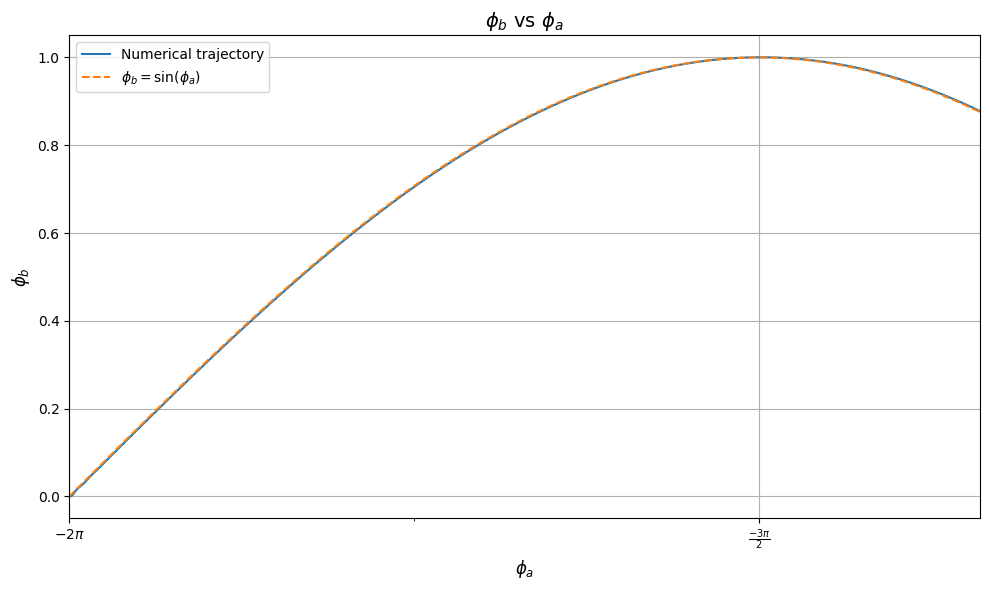

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

phi_a = trajectory[:, 0]
phi_b = trajectory[:, 1]

plt.figure(figsize=(10, 6))
plt.plot(phi_a, phi_b, label="Numerical trajectory")


phi_a_lin = np.linspace(phi_a.min(), phi_a.max(), 1000)
phi_b_theory = np.sin(phi_a_lin)
plt.plot(phi_a_lin, phi_b_theory, "--", label=r"$\phi_b = \sin(\phi_a)$")

plt.xlabel(r"$\phi_a$", fontsize=12)
plt.ylabel(r"$\phi_b$", fontsize=12)
plt.title(r"$\phi_b$ vs $\phi_a$", fontsize=14)
plt.legend()
plt.grid(True)


ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(base=np.pi/2))


def format_func(value, tick_number):
    
    N = int(np.round(value / (np.pi/2)))
    if N == 0:
        return "0"
    else:
    
        frac = N / 2
        if frac.is_integer():
            return r"${0}\pi$".format(int(frac))
        else:
            return r"$\frac{{{0}\pi}}{{2}}$".format(N)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))

ax.xaxis.set_minor_locator(ticker.MultipleLocator(base=np.pi/4))

plt.xlim(phi_a.min(), phi_a.max())

plt.tight_layout()
plt.show()


In [10]:
from inflatox.background import solve_eom 
solver = solve_eom(out)
trajectory = solver.calc_eom_array(
    args,             
    12000,            #step numbers
    [-2*np.pi, 0],        #initial condition of phi
    [0, 0],          #initial condition of phi_dot
    1e-5,           #step length,optional
    1e-6,           #max error,optional
    "rkf",         #optional
)

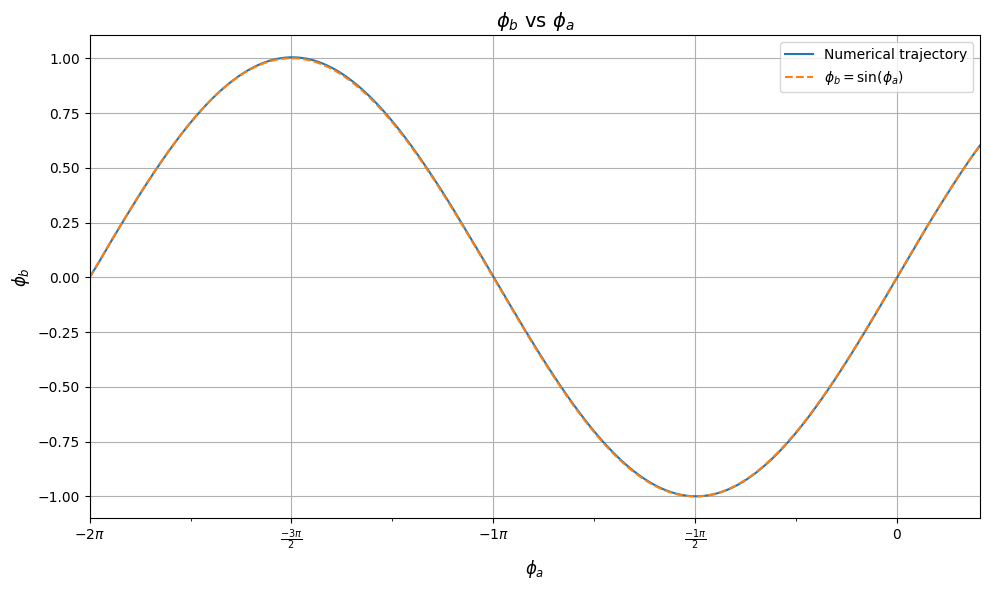

In [11]:
import numpy as np
import matplotlib.pyplot as plt

phi_a = trajectory[:, 0]
phi_b = trajectory[:, 1]

plt.figure(figsize=(10, 6))
plt.plot(phi_a, phi_b, label="Numerical trajectory")


phi_a_lin = np.linspace(phi_a.min(), phi_a.max(), 1000)
phi_b_theory = np.sin(phi_a_lin)
plt.plot(phi_a_lin, phi_b_theory, "--", label=r"$\phi_b = \sin(\phi_a)$")

plt.xlabel(r"$\phi_a$", fontsize=12)
plt.ylabel(r"$\phi_b$", fontsize=12)
plt.title(r"$\phi_b$ vs $\phi_a$", fontsize=14)
plt.legend()
plt.grid(True)


ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(base=np.pi/2))


def format_func(value, tick_number):
    
    N = int(np.round(value / (np.pi/2)))
    if N == 0:
        return "0"
    else:
    
        frac = N / 2
        if frac.is_integer():
            return r"${0}\pi$".format(int(frac))
        else:
            return r"$\frac{{{0}\pi}}{{2}}$".format(N)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))

ax.xaxis.set_minor_locator(ticker.MultipleLocator(base=np.pi/4))

plt.xlim(phi_a.min(), phi_a.max())

plt.tight_layout()
plt.show()